# Clinical-trial negative efficacy classifier

Google Colab notebook for classifying a single clinical-trial termination sentence into:

- **1 = negative efficacy / futility / endpoints not met**
- **0 = all other reasons**

This version focuses on:
- TF-IDF + Logistic Regression baseline
- **DeBERTa-v3-base**
- **SetFit**
- comparison against the public Open Targets / Razuvayevskaya proxy model and the group-presentation benchmarks
- calibrated probabilities, threshold tuning, and conformal prediction sets


In [1]:
!pip -q install -U "transformers>=4.46,<4.49" accelerate datasets scikit-learn joblib openpyxl setfit sentence-transformers

In [2]:
import os
import gc
import json
import math
import random
import shutil
import warnings
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.special import softmax
from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

from datasets import Dataset as HFDataset
from setfit import SetFitModel, SetFitTrainer

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


  Using cached scikit_learn-1.2.2-cp312-cp312-linux_x86_64.whl
  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
DEVICE: cuda


In [3]:
SHEET_NAME = "ST1"
HEADER_ROW = 2
TEXT_COL = "Reasons for termination"
LABEL_COLS = ["Reason1", "Reason2", "Reason3"]
STATUS_COL = "Status"
CATEGORY_COL = "Category"

POSITIVE_REASON_LABELS = {
    "Insufficient Efficacy",
    "Futility",
    "Unmet endpoint",
}

RELAXED_EXTRA_POSITIVE_LABELS = set([
    # Example if you later want it:
    # "Based on data in this study"
])

DROP_CONFLICTING_DUPLICATE_TEXTS = True
DROP_EMPTY_TEXTS = True

TEST_SIZE = 0.20
VAL_SIZE = 0.10
CAL_SIZE = 0.10

MAX_LEN = 96
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
NUM_EPOCHS = 7
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

SETFIT_NUM_EPOCHS = 1
SETFIT_NUM_ITERATIONS = 20
SETFIT_BATCH_SIZE = 64
SETFIT_LEARNING_RATE = 2e-5

MODELS_TO_RUN = {
    "logreg": True,
    "deberta_v3": True,
    "setfit": True,
}

HF_MODELS = {
    "deberta_v3": "microsoft/deberta-v3-base",
    "setfit": "sentence-transformers/paraphrase-mpnet-base-v2",
}

EXPORT_DIR = Path("/content/negative_efficacy_export") if IN_COLAB else Path("./negative_efficacy_export")
LOCAL_WORKBOOK_PATH = None
LOGREG_C_GRID = [2.0, 4.0]


In [4]:
def resolve_input_path(local_path=None):
    if local_path:
        p = Path(local_path)
        if p.exists():
            return p

    candidates = [
        Path("/content/41588_2024_1854_MOESM3_ESM.xlsx"),
        Path("./41588_2024_1854_MOESM3_ESM.xlsx"),
        Path("/mnt/data/41588_2024_1854_MOESM3_ESM.xlsx"),
    ]
    for p in candidates:
        if p.exists():
            return p

    if IN_COLAB:
        print("Upload the workbook now...")
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No workbook uploaded.")
        return Path(next(iter(uploaded.keys())))

    raise FileNotFoundError("Workbook not found. Set LOCAL_WORKBOOK_PATH or upload the file.")

WORKBOOK_PATH = resolve_input_path(LOCAL_WORKBOOK_PATH)
print("Using workbook:", WORKBOOK_PATH)

raw_df = pd.read_excel(WORKBOOK_PATH, sheet_name=SHEET_NAME, header=HEADER_ROW)
display(raw_df.head())
print(raw_df.shape)
print(raw_df.columns.tolist())

Upload the workbook now...


Saving 41588_2024_1854_MOESM3_ESM.xlsx to 41588_2024_1854_MOESM3_ESM.xlsx
Using workbook: 41588_2024_1854_MOESM3_ESM.xlsx


,Reason1,Reason2,Reason3,Concat,Count,Terminated Trial,Phase,Min Phase,NCT ID,Status,Category,Reasons for termination
0,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00757/NCT00757757.xml-32-,Phase 1/Phase 2,1,NCT00757757,Terminated,Suspicious,Novartis decided to terminate based on strateg...
1,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00408/NCT00408148.xml-47-,Phase 3,3,NCT00408148,Terminated,Suspicious,Company decision has been taken in light of re...
2,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00577/NCT00577148.xml-33-,Phase 3,3,NCT00577148,Terminated,Suspicious,Company decision taken in light of demands by ...
3,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00690/NCT00690456.xml-39-,Phase 3,3,NCT00690456,Terminated,Suspicious,Company decision taken in light of demands by ...
4,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00678/NCT00678483.xml-44-,Phase 3,3,NCT00678483,Terminated,Suspicious,Company decision taken in light of demands by ...


(3124, 12)
['Reason1', 'Reason2', 'Reason3', 'Concat', 'Count', 'Terminated Trial', 'Phase', 'Min Phase', 'NCT ID', 'Status', 'Category', 'Reasons for termination']


In [5]:
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("&amp;", "&")
    text = re.sub(r"\s+", " ", text.strip().lower())
    return text

def derive_binary_label(row, positive_labels):
    labels = {row.get(col) for col in LABEL_COLS if pd.notna(row.get(col))}
    return int(any(label in positive_labels for label in labels))

LOW_INFO_PATTERNS = [
    r"^see detailed description\.?$",
    r"^see termination reason in detailed description\.?$",
    r"^please see detailed description(?: below)? for termination reason\.?$",
]

def is_low_information_text(text_norm):
    return any(re.match(pat, text_norm) for pat in LOW_INFO_PATTERNS)

def build_binary_dataset(df, positive_labels, drop_conflicting_duplicate_texts=True):
    required = set(LABEL_COLS + [TEXT_COL, STATUS_COL, CATEGORY_COL])
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {sorted(missing)}")

    work = df.copy()

    if DROP_EMPTY_TEXTS:
        work = work.loc[work[TEXT_COL].notna()].copy()
        work = work.loc[work[TEXT_COL].astype(str).str.strip().ne("")].copy()

    work["text"] = work[TEXT_COL].astype(str)
    work["text_norm"] = work["text"].map(normalize_text)
    work["label"] = work.apply(lambda row: derive_binary_label(row, positive_labels), axis=1).astype(int)
    work["low_information_text"] = work["text_norm"].map(is_low_information_text)

    work["reason_labels"] = work[LABEL_COLS].apply(
        lambda row: sorted({v for v in row.values.tolist() if pd.notna(v)}),
        axis=1,
    )

    label_nunique_by_text = work.groupby("text_norm")["label"].nunique()
    conflict_texts = set(label_nunique_by_text[label_nunique_by_text > 1].index)
    work["text_conflict"] = work["text_norm"].isin(conflict_texts)

    if drop_conflicting_duplicate_texts:
        work = work.loc[~work["text_conflict"]].copy()

    work = work.reset_index(drop=True)
    return work, conflict_texts

binary_df, conflict_texts = build_binary_dataset(
    raw_df,
    POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS,
    drop_conflicting_duplicate_texts=DROP_CONFLICTING_DUPLICATE_TEXTS,
)

print("Rows after preprocessing:", len(binary_df))
print("Positive rows:", int(binary_df["label"].sum()))
print("Positive rate:", round(float(binary_df["label"].mean()), 4))
print("Conflicting normalized texts removed:", len(conflict_texts))
print("Low-information rows flagged:", int(binary_df["low_information_text"].sum()))
display(binary_df[[TEXT_COL, "label", "reason_labels", "low_information_text"]].head(10))

Rows after preprocessing: 3022
Positive rows: 239
Positive rate: 0.0791
Conflicting normalized texts removed: 10
Low-information rows flagged: 0


,Reasons for termination,label,reason_labels,low_information_text
0,Novartis decided to terminate based on strateg...,0,"[Administrative reasons, Business decision]",False
1,Company decision has been taken in light of re...,0,"[Administrative reasons, Business decision]",False
2,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
3,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
4,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
5,Company decision has been taken in light of re...,0,"[Administrative reasons, Business decision]",False
6,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
7,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
8,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
9,Company decision has been taken in light of re...,0,"[Administrative reasons, Business decision]",False


In [6]:
print("Category distribution")
display(binary_df[CATEGORY_COL].value_counts(dropna=False).to_frame("count"))

print("Status distribution")
display(binary_df[STATUS_COL].value_counts(dropna=False).to_frame("count"))

print("Positive examples")
display(
    binary_df.loc[binary_df["label"] == 1, [TEXT_COL, "reason_labels"]]
    .sample(min(12, int(binary_df["label"].sum())), random_state=SEED)
)

print("Conflicting texts removed (sample)")
for x in list(sorted(conflict_texts))[:10]:
    print("-", x)

Category distribution


,count
Category,
Neutral,1660
Suspicious,623
Negative,304
Misuse,236
Safety,182
Positive,17


Status distribution


,count
Status,
Terminated,2257
Withdrawn,457
Suspended,308


Positive examples


,Reasons for termination,reason_labels
860,The study was terminated on the basis of futil...,"[Futility, Insufficient Efficacy]"
99,Study was terminated due to insufficient clini...,"[Another study, Insufficient Efficacy]"
966,Efficacy seen in the solid tumour patient popu...,[Insufficient Efficacy]
982,Primary efficacy analysis at Week 24 did not d...,[Insufficient Efficacy]
977,lack of efficacy,[Insufficient Efficacy]
1045,Lack of Efficacy.,[Insufficient Efficacy]
1073,Study was stopped after pre-definied interim a...,[Insufficient Efficacy]
959,&quot;Tapering doses&quot; protocol arm was no...,[Insufficient Efficacy]
102,Negative efficacy results of the MAESTRO-01 study,"[Another study, Insufficient Efficacy]"
1015,The planned enrollment was 130 patients and th...,[Insufficient Efficacy]


Conflicting texts removed (sample)
- emd serono voluntarily decided to terminate this trial after observing increased ms disease activity in trial 28063 atams [please refer to atams]
- enrollment suspended based upon interim analysis; subjects allowed to stay on study until disease progression.
- please see detailed description below for termination reason.
- please see detailed description for termination reason.
- see detailed description
- see detailed description for termination reason
- see detailed description for termination reason.
- see detailed description.
- see termination reason in detailed description
- see termination reason in detailed description.


In [7]:
def make_group_splits(df, group_col="text_norm", label_col="label", test_size=0.2, val_size=0.1, cal_size=0.1, seed=42):
    if test_size + val_size + cal_size >= 1.0:
        raise ValueError("test_size + val_size + cal_size must be < 1.0")

    groups = df[[group_col, label_col]].drop_duplicates().reset_index(drop=True)

    train_val_cal_groups, test_groups = train_test_split(
        groups,
        test_size=test_size,
        random_state=seed,
        stratify=groups[label_col],
    )

    remaining_after_test = 1.0 - test_size
    val_rel = val_size / remaining_after_test

    train_cal_groups, val_groups = train_test_split(
        train_val_cal_groups,
        test_size=val_rel,
        random_state=seed,
        stratify=train_val_cal_groups[label_col],
    )

    remaining_after_test_val = remaining_after_test - val_size
    cal_rel = cal_size / remaining_after_test_val

    train_groups, cal_groups = train_test_split(
        train_cal_groups,
        test_size=cal_rel,
        random_state=seed,
        stratify=train_cal_groups[label_col],
    )

    split_map = {}
    for split_name, split_part in {
        "train": train_groups,
        "val": val_groups,
        "cal": cal_groups,
        "test": test_groups,
    }.items():
        for key in split_part[group_col]:
            split_map[key] = split_name

    out = df.copy()
    out["split"] = out[group_col].map(split_map)
    assert out["split"].isna().sum() == 0
    return out

split_df = make_group_splits(
    binary_df,
    group_col="text_norm",
    label_col="label",
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    cal_size=CAL_SIZE,
    seed=SEED,
)

for split_name in ["train", "val", "cal", "test"]:
    sub = split_df.loc[split_df["split"] == split_name]
    print(
        split_name,
        {
            "rows": len(sub),
            "positive_rows": int(sub["label"].sum()),
            "positive_rate": round(float(sub["label"].mean()), 4),
            "unique_groups": sub["text_norm"].nunique(),
        },
    )

train_df = split_df.loc[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df.loc[split_df["split"] == "val"].reset_index(drop=True)
cal_df = split_df.loc[split_df["split"] == "cal"].reset_index(drop=True)
test_df = split_df.loc[split_df["split"] == "test"].reset_index(drop=True)

train {'rows': 1748, 'positive_rows': 137, 'positive_rate': 0.0784, 'unique_groups': 1446}
val {'rows': 290, 'positive_rows': 22, 'positive_rate': 0.0759, 'unique_groups': 242}
cal {'rows': 320, 'positive_rows': 34, 'positive_rate': 0.1062, 'unique_groups': 242}
test {'rows': 664, 'positive_rows': 46, 'positive_rate': 0.0693, 'unique_groups': 483}


In [8]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        ece += np.abs(y_true[mask].mean() - y_prob[mask].mean()) * mask.mean()
    return float(ece)

def best_f1_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    thresholds = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), y_prob]))
    best_t = 0.5
    best_score = -1.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = float(t)
    return best_t, float(best_score)

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "average_precision": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "ece_10": expected_calibration_error(y_true, y_prob, n_bins=10),
        "threshold": threshold,
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        out["roc_auc"] = np.nan
    return out

def plot_model_diagnostics(y_true, y_prob, threshold=0.5, title_prefix=""):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0].plot(fpr, tpr)
        axes[0].plot([0, 1], [0, 1], linestyle="--")
        axes[0].set_title(f"{title_prefix} ROC")
        axes[0].set_xlabel("FPR")
        axes[0].set_ylabel("TPR")
    except Exception:
        axes[0].text(0.5, 0.5, "ROC unavailable", ha="center", va="center")

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    axes[1].plot(rec, prec)
    axes[1].set_title(f"{title_prefix} PR")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")

    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    axes[2].plot(mean_pred, frac_pos, marker="o")
    axes[2].plot([0, 1], [0, 1], linestyle="--")
    axes[2].set_title(f"{title_prefix} Reliability")

    cm = confusion_matrix(y_true, y_pred)
    axes[3].imshow(cm)
    axes[3].set_title(f"{title_prefix} Confusion @ {threshold:.3f}")
    axes[3].set_xticks([0, 1], labels=["Other", "Neg efficacy"])
    axes[3].set_yticks([0, 1], labels=["Other", "Neg efficacy"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[3].text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

class SigmoidScoreCalibrator:
    def __init__(self):
        self.model = LogisticRegression(solver="lbfgs")

    def fit(self, scores, y):
        self.model.fit(np.asarray(scores).reshape(-1, 1), np.asarray(y).astype(int))
        return self

    def predict_proba(self, scores):
        return self.model.predict_proba(np.asarray(scores).reshape(-1, 1))[:, 1]

def fit_split_conformal(prob_pos, y_true, alpha=0.10):
    prob_pos = np.asarray(prob_pos).astype(float)
    y_true = np.asarray(y_true).astype(int)
    true_prob = np.where(y_true == 1, prob_pos, 1.0 - prob_pos)
    nonconformity = 1.0 - true_prob
    n = len(nonconformity)
    q = min(math.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    try:
        qhat = np.quantile(nonconformity, q, method="higher")
    except TypeError:
        qhat = np.quantile(nonconformity, q, interpolation="higher")
    return float(qhat)

def conformal_prediction_sets(prob_pos, qhat):
    prob_pos = np.asarray(prob_pos).astype(float)
    out = []
    for p1 in prob_pos:
        p0 = 1.0 - p1
        pred_set = []
        if 1.0 - p0 <= qhat:
            pred_set.append(0)
        if 1.0 - p1 <= qhat:
            pred_set.append(1)
        out.append(pred_set)
    return out

In [9]:
RESULTS = {}
ARTIFACTS = {}

,0
accuracy,0.962349
precision,0.744186
recall,0.695652
f1,0.719101
average_precision,0.832117
brier,0.030301
ece_10,0.02013
threshold,0.648485
roc_auc,0.978683
model_name,TFIDF+LogReg


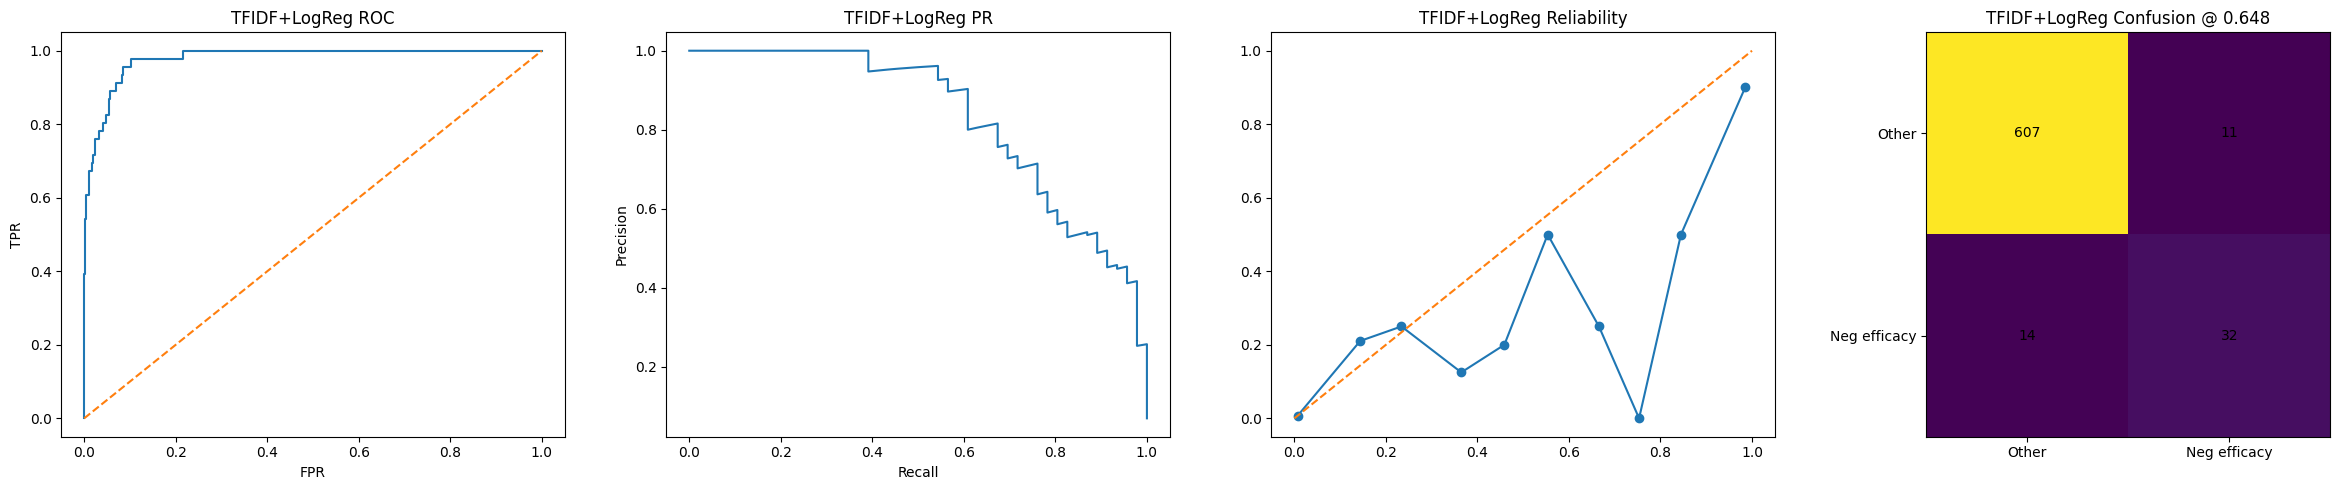

In [10]:
def train_logistic_baseline(train_df, val_df, cal_df, test_df):
    vectorizer = FeatureUnion([
        ("word", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
        )),
    ])

    X_train = vectorizer.fit_transform(train_df["text"])
    X_val = vectorizer.transform(val_df["text"])
    X_cal = vectorizer.transform(cal_df["text"])
    X_test = vectorizer.transform(test_df["text"])

    y_train = train_df["label"].to_numpy()
    y_val = val_df["label"].to_numpy()
    y_cal = cal_df["label"].to_numpy()
    y_test = test_df["label"].to_numpy()

    best = None
    for c in LOGREG_C_GRID:
        clf = LogisticRegression(C=c, class_weight="balanced", max_iter=4000, solver="liblinear")
        clf.fit(X_train, y_train)
        val_prob = clf.predict_proba(X_val)[:, 1]
        ap = average_precision_score(y_val, val_prob)
        if best is None or ap > best["val_ap"]:
            best = {"C": c, "clf": clf, "val_ap": ap}

    clf = best["clf"]
    cal_scores = clf.decision_function(X_cal)
    calibrator = SigmoidScoreCalibrator().fit(cal_scores, y_cal)

    val_prob = calibrator.predict_proba(clf.decision_function(X_val))
    test_prob = calibrator.predict_proba(clf.decision_function(X_test))
    threshold, _ = best_f1_threshold(y_val, val_prob)
    metrics = compute_binary_metrics(y_test, test_prob, threshold=threshold)

    cal_prob = calibrator.predict_proba(cal_scores)
    qhat = fit_split_conformal(cal_prob, y_cal, alpha=0.10)

    artifacts = {
        "type": "logreg",
        "vectorizer": vectorizer,
        "model": clf,
        "calibrator": calibrator,
        "threshold": threshold,
        "qhat": qhat,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
    }
    aux = {
        "test_prob": test_prob,
        "y_test": y_test,
        "best_C": best["C"],
    }
    return metrics, artifacts, aux

if MODELS_TO_RUN["logreg"]:
    metrics, artifacts, aux = train_logistic_baseline(train_df, val_df, cal_df, test_df)
    RESULTS["logreg"] = metrics | {"model_name": "TFIDF+LogReg", "best_C": aux["best_C"]}
    ARTIFACTS["logreg"] = artifacts
    display(pd.DataFrame([RESULTS["logreg"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="TFIDF+LogReg")

In [11]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = list(texts)
        self.labels = None if labels is None else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weight = None if self.class_weights is None else self.class_weights.to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weight)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax(logits, axis=1)[:, 1]
    preds = (probs >= 0.5).astype(int)
    out = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "average_precision": average_precision_score(labels, probs),
    }
    try:
        out["roc_auc"] = roc_auc_score(labels, probs)
    except Exception:
        out["roc_auc"] = np.nan
    return out

def predict_logits(model, tokenizer, texts, batch_size=32, max_length=96):
    ds = TextDataset(texts, labels=None, tokenizer=tokenizer, max_length=max_length)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_logits = []
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            all_logits.append(outputs.logits.detach().cpu().numpy())
    return np.vstack(all_logits)

def fit_temperature(logits, y_true, max_iter=50):
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(np.asarray(y_true).astype(int), dtype=torch.long)
    temperature = nn.Parameter(torch.ones(1))
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=max_iter)
    nll = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = nll(logits_t / temperature.clamp(min=1e-3), labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(temperature.detach().clamp(min=1e-3).cpu().item())

def apply_temperature(logits, temperature):
    return softmax(logits / float(temperature), axis=1)[:, 1]

In [12]:
def train_transformer_model(model_key, model_name, train_df, val_df, cal_df, test_df):
    seed_everything(SEED)
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.to(DEVICE)

    train_ds = TextDataset(train_df["text"], train_df["label"], tokenizer, max_length=MAX_LEN)
    val_ds = TextDataset(val_df["text"], val_df["label"], tokenizer, max_length=MAX_LEN)

    class_counts = train_df["label"].value_counts().sort_index()
    total = int(class_counts.sum())
    class_weights = torch.tensor(
        [total / max(int(class_counts.get(0, 1)), 1), total / max(int(class_counts.get(1, 1)), 1)],
        dtype=torch.float32,
    )

    output_dir = Path("./trainer_outputs") / model_key
    output_dir.mkdir(parents=True, exist_ok=True)

    args = TrainingArguments(
        output_dir=str(output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_average_precision",
        greater_is_better=True,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available(),
        dataloader_pin_memory=torch.cuda.is_available(),
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        class_weights=class_weights,
        compute_metrics=hf_compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()

    val_logits = predict_logits(model, tokenizer, val_df["text"].tolist(), batch_size=EVAL_BATCH_SIZE, max_length=MAX_LEN)
    cal_logits = predict_logits(model, tokenizer, cal_df["text"].tolist(), batch_size=EVAL_BATCH_SIZE, max_length=MAX_LEN)
    test_logits = predict_logits(model, tokenizer, test_df["text"].tolist(), batch_size=EVAL_BATCH_SIZE, max_length=MAX_LEN)

    temperature = fit_temperature(cal_logits, cal_df["label"].to_numpy())
    val_prob = apply_temperature(val_logits, temperature)
    cal_prob = apply_temperature(cal_logits, temperature)
    test_prob = apply_temperature(test_logits, temperature)

    threshold, _ = best_f1_threshold(val_df["label"].to_numpy(), val_prob)
    metrics = compute_binary_metrics(test_df["label"].to_numpy(), test_prob, threshold=threshold)
    qhat = fit_split_conformal(cal_prob, cal_df["label"].to_numpy(), alpha=0.10)

    artifacts = {
        "type": "transformer",
        "model_key": model_key,
        "model_name": model_name,
        "tokenizer": tokenizer,
        "model": model,
        "temperature": temperature,
        "threshold": threshold,
        "qhat": qhat,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
    }
    aux = {
        "test_prob": test_prob,
        "y_test": test_df["label"].to_numpy(),
    }
    return metrics, artifacts, aux

def _to_hf_dataset(df):
    return HFDataset.from_pandas(
        df[["text", "label"]].reset_index(drop=True),
        preserve_index=False,
    )

def _as_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)

def _prob_to_logit(prob, eps=1e-6):
    prob = np.clip(np.asarray(prob).astype(float), eps, 1.0 - eps)
    return np.log(prob / (1.0 - prob))

def train_setfit_model(model_key, model_name, train_df, val_df, cal_df, test_df):
    seed_everything(SEED)

    train_ds = _to_hf_dataset(train_df)
    val_ds = _to_hf_dataset(val_df)

    model = SetFitModel.from_pretrained(model_name)
    try:
        model.to(DEVICE)
    except Exception:
        pass

    trainer = SetFitTrainer(
        model=model,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        metric="f1",
        metric_kwargs={"average": "binary"},
        batch_size=SETFIT_BATCH_SIZE,
        num_epochs=SETFIT_NUM_EPOCHS,
        num_iterations=SETFIT_NUM_ITERATIONS,
        learning_rate=SETFIT_LEARNING_RATE,
        column_mapping={"text": "text", "label": "label"},
        use_amp=torch.cuda.is_available(),
    )
    trainer.train()

    val_prob_raw = _as_numpy(model.predict_proba(val_df["text"].tolist()))[:, 1]
    cal_prob_raw = _as_numpy(model.predict_proba(cal_df["text"].tolist()))[:, 1]
    test_prob_raw = _as_numpy(model.predict_proba(test_df["text"].tolist()))[:, 1]

    calibrator = SigmoidScoreCalibrator().fit(_prob_to_logit(cal_prob_raw), cal_df["label"].to_numpy())
    val_prob = calibrator.predict_proba(_prob_to_logit(val_prob_raw))
    cal_prob = calibrator.predict_proba(_prob_to_logit(cal_prob_raw))
    test_prob = calibrator.predict_proba(_prob_to_logit(test_prob_raw))

    threshold, _ = best_f1_threshold(val_df["label"].to_numpy(), val_prob)
    metrics = compute_binary_metrics(test_df["label"].to_numpy(), test_prob, threshold=threshold)
    qhat = fit_split_conformal(cal_prob, cal_df["label"].to_numpy(), alpha=0.10)

    artifacts = {
        "type": "setfit",
        "model_key": model_key,
        "model_name": model_name,
        "model": model,
        "calibrator": calibrator,
        "threshold": threshold,
        "qhat": qhat,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
    }
    aux = {
        "test_prob": test_prob,
        "test_prob_raw": test_prob_raw,
        "y_test": test_df["label"].to_numpy(),
    }
    return metrics, artifacts, aux


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


,0
accuracy,0.957831
precision,0.764706
recall,0.565217
f1,0.65
average_precision,0.786066
brier,0.033591
ece_10,0.024718
threshold,0.915758
roc_auc,0.959987
model_name,distilbert/distilbert-base-uncased


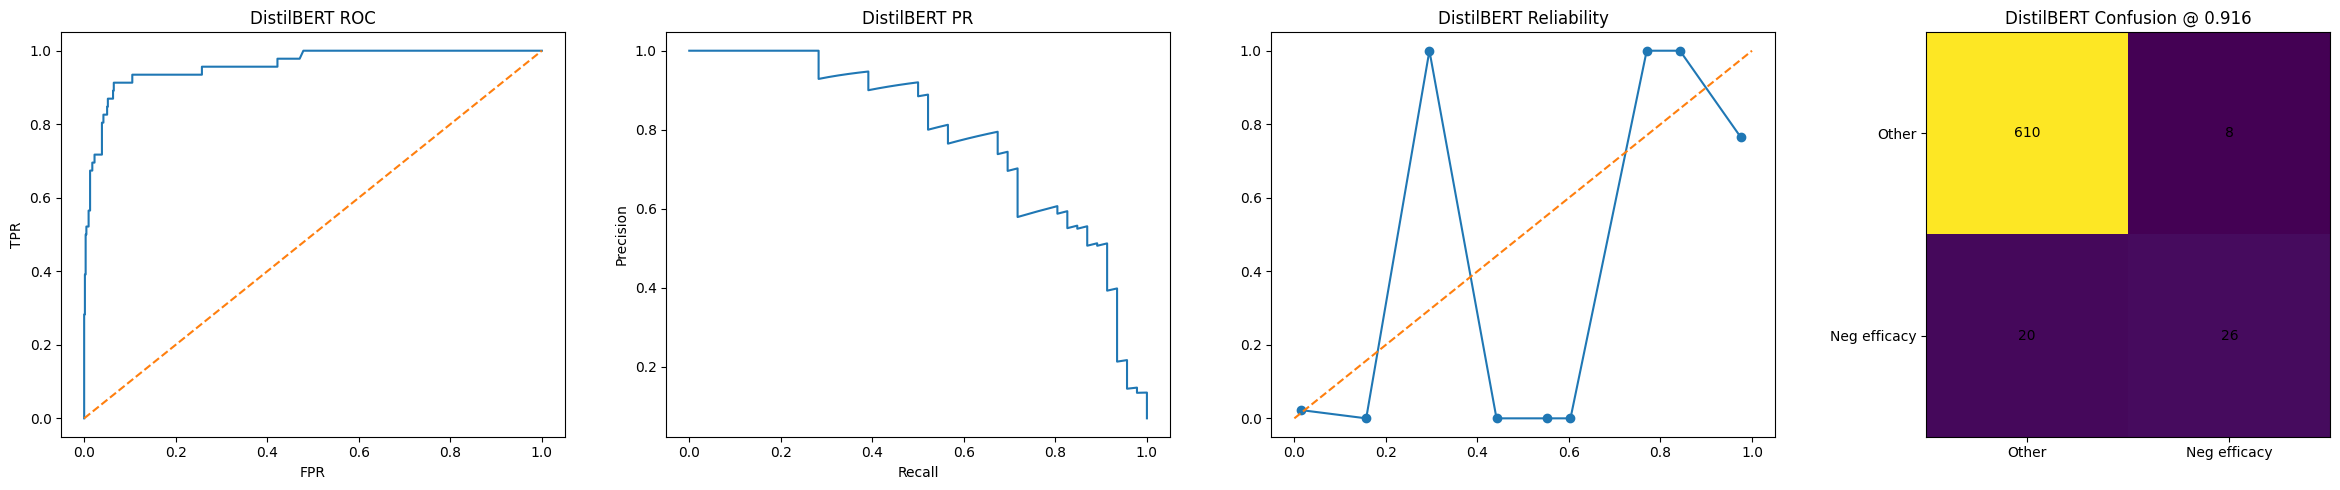

In [13]:
if MODELS_TO_RUN["deberta_v3"]:
    metrics, artifacts, aux = train_transformer_model(
        "deberta_v3",
        HF_MODELS["deberta_v3"],
        train_df,
        val_df,
        cal_df,
        test_df,
    )
    RESULTS["deberta_v3"] = metrics | {"model_name": HF_MODELS["deberta_v3"]}
    ARTIFACTS["deberta_v3"] = artifacts
    display(pd.DataFrame([RESULTS["deberta_v3"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="DeBERTa-v3")


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

,0
accuracy,0.971386
precision,0.764706
recall,0.847826
f1,0.804124
average_precision,0.843325
brier,0.024998
ece_10,0.023622
threshold,0.081567
roc_auc,0.970944
model_name,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...


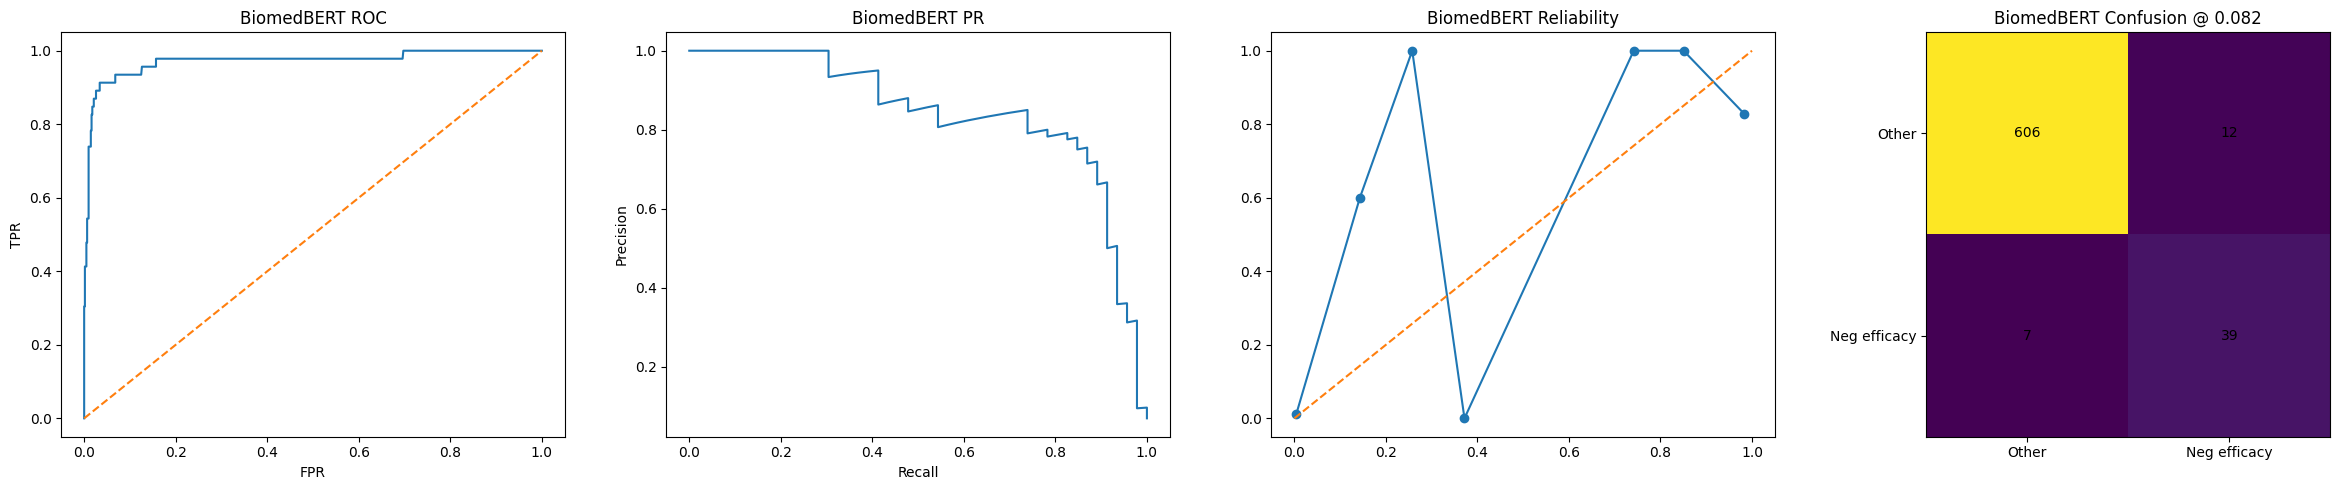

In [14]:
if MODELS_TO_RUN["setfit"]:
    metrics, artifacts, aux = train_setfit_model(
        "setfit",
        HF_MODELS["setfit"],
        train_df,
        val_df,
        cal_df,
        test_df,
    )
    RESULTS["setfit"] = metrics | {"model_name": f"SetFit({HF_MODELS['setfit']})"}
    ARTIFACTS["setfit"] = artifacts
    display(pd.DataFrame([RESULTS["setfit"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="SetFit")


In [15]:
results_df = pd.DataFrame(RESULTS).T.sort_values(by=["average_precision", "f1", "roc_auc"], ascending=False)
display(results_df)
BEST_MODEL_KEY = results_df.index[0]
print("Selected best model:", BEST_MODEL_KEY)

,accuracy,precision,recall,f1,average_precision,brier,ece_10,threshold,roc_auc,model_name,best_C
biomedbert,0.971386,0.764706,0.847826,0.804124,0.843325,0.024998,0.023622,0.081567,0.970944,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...,NaN
logreg,0.962349,0.744186,0.695652,0.719101,0.832117,0.030301,0.02013,0.648485,0.978683,TFIDF+LogReg,4.0
distilbert,0.957831,0.764706,0.565217,0.65,0.786066,0.033591,0.024718,0.915758,0.959987,distilbert/distilbert-base-uncased,NaN


Selected best model: biomedbert


In [16]:
def _score_logreg(artifact, texts):
    X = artifact["vectorizer"].transform(list(texts))
    raw_scores = artifact["model"].decision_function(X)
    prob_pos = artifact["calibrator"].predict_proba(raw_scores)
    return prob_pos, raw_scores

def _score_transformer(artifact, texts):
    logits = predict_logits(
        artifact["model"],
        artifact["tokenizer"],
        list(texts),
        batch_size=EVAL_BATCH_SIZE,
        max_length=MAX_LEN,
    )
    prob_pos = apply_temperature(logits, artifact["temperature"])
    margin = np.abs(prob_pos - 0.5) * 2.0
    return prob_pos, margin

def _score_setfit(artifact, texts):
    prob_raw = _as_numpy(artifact["model"].predict_proba(list(texts)))[:, 1]
    raw_scores = _prob_to_logit(prob_raw)
    prob_pos = artifact["calibrator"].predict_proba(raw_scores)
    return prob_pos, raw_scores

def predict_texts(texts, model_key=None):
    if model_key is None:
        model_key = BEST_MODEL_KEY

    artifact = ARTIFACTS[model_key]
    texts = list(texts)

    if artifact["type"] == "logreg":
        prob_pos, secondary = _score_logreg(artifact, texts)
        confidence_name = "raw_log_odds"
    elif artifact["type"] == "setfit":
        prob_pos, secondary = _score_setfit(artifact, texts)
        confidence_name = "setfit_logit"
    else:
        prob_pos, secondary = _score_transformer(artifact, texts)
        confidence_name = "margin_from_0.5"

    pred_sets = conformal_prediction_sets(prob_pos, artifact["qhat"])
    point_preds = (prob_pos >= artifact["threshold"]).astype(int)

    rows = []
    for text, p1, pred, pred_set, sec in zip(texts, prob_pos, point_preds, pred_sets, secondary):
        if pred_set == [1]:
            decision = "predict_negative_efficacy"
        elif pred_set == [0]:
            decision = "predict_other_reason"
        else:
            decision = "review"

        rows.append({
            "text": text,
            "prob_negative_efficacy": float(p1),
            "point_prediction": int(pred),
            "prediction_set": str(pred_set),
            "decision": decision,
            confidence_name: float(sec),
        })
    return pd.DataFrame(rows)

demo_texts = [
    "Study was terminated after interim analysis showed futility and lack of efficacy.",
    "Trial stopped because of slow recruitment and lack of funding.",
    "Please see detailed description for termination reason.",
]
display(predict_texts(demo_texts))


,text,prob_negative_efficacy,point_prediction,prediction_set,decision,margin_from_0.5
0,Study was terminated after interim analysis sh...,0.994102,1,[1],predict_negative_efficacy,0.988204
1,Trial stopped because of slow recruitment and ...,0.003150,0,[0],predict_other_reason,0.993699
2,Please see detailed description for terminatio...,0.015509,0,[],review,0.968982


In [17]:
def enable_dropout(model):
    for module in model.modules():
        if module.__class__.__name__.startswith("Dropout"):
            module.train()

def mc_dropout_predict_proba(model, tokenizer, texts, n_passes=20, batch_size=32, max_length=96):
    ds = TextDataset(texts, labels=None, tokenizer=tokenizer, max_length=max_length)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    probs_passes = []
    model.eval()
    enable_dropout(model)

    with torch.no_grad():
        for _ in range(n_passes):
            probs_this_pass = []
            for batch in dl:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = model(**batch).logits
                probs_this_pass.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())
            probs_passes.append(np.concatenate(probs_this_pass))

    probs_passes = np.stack(probs_passes, axis=0)
    return probs_passes.mean(axis=0), probs_passes.std(axis=0)

if BEST_MODEL_KEY in {"deberta_v3"}:
    mean_prob, std_prob = mc_dropout_predict_proba(
        ARTIFACTS[BEST_MODEL_KEY]["model"],
        ARTIFACTS[BEST_MODEL_KEY]["tokenizer"],
        demo_texts,
        n_passes=10,
        batch_size=8,
        max_length=MAX_LEN,
    )
    display(pd.DataFrame({
        "text": demo_texts,
        "mc_dropout_mean_prob": mean_prob,
        "mc_dropout_std": std_prob,
    }))
else:
    print("Best model is not a transformer with token-level dropout access; skipping MC dropout.")


,text,mc_dropout_mean_prob,mc_dropout_std
0,Study was terminated after interim analysis sh...,0.996242,0.000845
1,Trial stopped because of slow recruitment and ...,0.001597,0.000312
2,Please see detailed description for terminatio...,0.008929,0.002748


In [18]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def export_artifacts(results_df, export_dir=EXPORT_DIR):
    export_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "sheet_name": SHEET_NAME,
        "text_col": TEXT_COL,
        "label_cols": LABEL_COLS,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
        "best_model_key": BEST_MODEL_KEY,
        "results": results_df.reset_index(names="model_key").to_dict(orient="records"),
    }
    with open(export_dir / "run_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    for model_key, artifact in ARTIFACTS.items():
        if artifact["type"] == "logreg":
            joblib.dump({
                "vectorizer": artifact["vectorizer"],
                "model": artifact["model"],
                "calibrator": artifact["calibrator"],
                "threshold": artifact["threshold"],
                "qhat": artifact["qhat"],
                "positive_reason_labels": artifact["positive_reason_labels"],
            }, export_dir / f"{model_key}_bundle.joblib")
        elif artifact["type"] == "setfit":
            model_dir = export_dir / model_key
            model_dir.mkdir(exist_ok=True, parents=True)
            artifact["model"].save_pretrained(model_dir)
            joblib.dump(artifact["calibrator"], model_dir / "calibrator.joblib")
            with open(model_dir / "posthoc_config.json", "w") as f:
                json.dump({
                    "model_name": artifact["model_name"],
                    "threshold": artifact["threshold"],
                    "qhat": artifact["qhat"],
                    "positive_reason_labels": artifact["positive_reason_labels"],
                }, f, indent=2)
        else:
            model_dir = export_dir / model_key
            model_dir.mkdir(exist_ok=True, parents=True)
            artifact["model"].save_pretrained(model_dir)
            artifact["tokenizer"].save_pretrained(model_dir)
            with open(model_dir / "posthoc_config.json", "w") as f:
                json.dump({
                    "model_name": artifact["model_name"],
                    "temperature": artifact["temperature"],
                    "threshold": artifact["threshold"],
                    "qhat": artifact["qhat"],
                    "positive_reason_labels": artifact["positive_reason_labels"],
                }, f, indent=2)

    zip_path = shutil.make_archive(str(export_dir), "zip", export_dir)
    return Path(zip_path)

zip_path = export_artifacts(results_df, EXPORT_DIR)
print("Exported:", zip_path)

if IN_COLAB:
    files.download(str(zip_path))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Exported: /content/negative_efficacy_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# --- Razuvayevskaya / Open Targets + group-presentation comparison ---
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification

MODEL_ID = "opentargets/clinical_trial_stop_reasons"
DEVICE_LOCAL = globals().get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN_LOCAL = globals().get("MAX_LEN", 96)
EVAL_BATCH_LOCAL = globals().get("EVAL_BATCH_SIZE", 32)

required_names = ["train_df", "val_df", "cal_df", "test_df"]
missing = [x for x in required_names if x not in globals()]
if missing:
    raise RuntimeError(f"Missing notebook variables required for comparison: {missing}")

def _find_negative_index(config):
    label2id = getattr(config, "label2id", None) or {}
    if "Negative" in label2id:
        return int(label2id["Negative"])

    id2label = getattr(config, "id2label", None) or {}
    for k, v in id2label.items():
        if str(v).strip().lower() == "negative":
            return int(k) if isinstance(k, str) and k.isdigit() else int(k)
    for k, v in id2label.items():
        if "negative" in str(v).strip().lower():
            return int(k) if isinstance(k, str) and k.isdigit() else int(k)

    raise ValueError(
        f"Could not find 'Negative' label in config. "
        f"label2id={label2id}, id2label={id2label}"
    )

class _SimpleTextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_length=96):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {k: v.squeeze(0) for k, v in enc.items()}

def _predict_logits(texts, tokenizer, model, batch_size=32, max_length=96, device="cpu"):
    ds = _SimpleTextDataset(texts, tokenizer=tokenizer, max_length=max_length)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    all_logits = []
    model.eval()
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits.detach().cpu().numpy()
            all_logits.append(logits)
    return np.concatenate(all_logits, axis=0)

def _negative_scores_and_probs(logits, config, neg_idx):
    logits = np.asarray(logits)

    if logits.ndim == 1:
        scores = logits.astype(float)
        probs = 1.0 / (1.0 + np.exp(-scores))
        return scores, probs

    problem_type = getattr(config, "problem_type", None)
    if problem_type == "single_label_classification":
        z = logits - logits.max(axis=1, keepdims=True)
        probs_all = np.exp(z) / np.exp(z).sum(axis=1, keepdims=True)
        scores = logits[:, neg_idx].astype(float)
        probs = probs_all[:, neg_idx].astype(float)
    else:
        scores = logits[:, neg_idx].astype(float)
        probs = 1.0 / (1.0 + np.exp(-scores))

    return scores, probs

def _binary_metrics(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "AUROC": float(roc_auc_score(y_true, y_prob)),
        "AUPRC": float(average_precision_score(y_true, y_prob)),
        "B.Acc": float(balanced_accuracy_score(y_true, y_pred)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Threshold": float(threshold),
        "N_test": int(len(y_true)),
        "Pos_test": int(y_true.sum()),
    }

def _best_f1_threshold_local(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    thresholds = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), y_prob]))
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_f1:
            best_t, best_f1 = float(t), float(score)
    return best_t, best_f1

cfg = AutoConfig.from_pretrained(MODEL_ID)
tok = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID).to(DEVICE_LOCAL)
neg_idx = _find_negative_index(cfg)

val_logits = _predict_logits(val_df["text"].tolist(), tok, model, batch_size=EVAL_BATCH_LOCAL, max_length=MAX_LEN_LOCAL, device=DEVICE_LOCAL)
cal_logits = _predict_logits(cal_df["text"].tolist(), tok, model, batch_size=EVAL_BATCH_LOCAL, max_length=MAX_LEN_LOCAL, device=DEVICE_LOCAL)
test_logits = _predict_logits(test_df["text"].tolist(), tok, model, batch_size=EVAL_BATCH_LOCAL, max_length=MAX_LEN_LOCAL, device=DEVICE_LOCAL)

val_scores, val_prob_raw = _negative_scores_and_probs(val_logits, cfg, neg_idx)
cal_scores, cal_prob_raw = _negative_scores_and_probs(cal_logits, cfg, neg_idx)
test_scores, test_prob_raw = _negative_scores_and_probs(test_logits, cfg, neg_idx)

platt = LogisticRegression(solver="lbfgs", max_iter=2000)
platt.fit(cal_scores.reshape(-1, 1), cal_df["label"].astype(int).to_numpy())

val_prob = platt.predict_proba(val_scores.reshape(-1, 1))[:, 1]
test_prob = platt.predict_proba(test_scores.reshape(-1, 1))[:, 1]

threshold, best_val_f1 = _best_f1_threshold_local(val_df["label"].to_numpy(), val_prob)
ot_metrics = _binary_metrics(test_df["label"].to_numpy(), test_prob, threshold=threshold)

comparison_rows = [{
    "Method": "Open Targets / Razuvayevskaya HF model (Negative head)",
    "Source": "Released HF model, evaluated on this notebook split",
    **ot_metrics,
    "Published_Fmicro": np.nan,
    "Comparable?": "Closest binary proxy",
}]

if "ARTIFACTS" in globals():
    for model_key, artifact in ARTIFACTS.items():
        if artifact["type"] == "logreg":
            prob_pos, _ = _score_logreg(artifact, test_df["text"].tolist())
        elif artifact["type"] == "setfit":
            prob_pos, _ = _score_setfit(artifact, test_df["text"].tolist())
        else:
            prob_pos, _ = _score_transformer(artifact, test_df["text"].tolist())

        y_true = test_df["label"].to_numpy().astype(int)
        y_pred = (prob_pos >= artifact["threshold"]).astype(int)

        comparison_rows.append({
            "Method": RESULTS.get(model_key, {}).get("model_name", model_key),
            "Source": "This notebook",
            "AUROC": float(roc_auc_score(y_true, prob_pos)),
            "AUPRC": float(average_precision_score(y_true, prob_pos)),
            "B.Acc": float(balanced_accuracy_score(y_true, y_pred)),
            "F1": float(f1_score(y_true, y_pred, zero_division=0)),
            "Threshold": float(artifact["threshold"]),
            "N_test": int(len(y_true)),
            "Pos_test": int(y_true.sum()),
            "Published_Fmicro": np.nan,
            "Comparable?": "Yes",
        })

slide_reference_rows = [
    {"Method": "TF-IDF + Linear Regression", "Source": "Group presentation", "AUROC": 0.963, "AUPRC": 0.736, "B.Acc": 0.846, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "TF-IDF + Random Forest", "Source": "Group presentation", "AUROC": 0.954, "AUPRC": 0.688, "B.Acc": 0.745, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "fastText + Linear Regression", "Source": "Group presentation", "AUROC": 0.892, "AUPRC": 0.469, "B.Acc": 0.824, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Mostly"},
    {"Method": "fastText + Random Forest", "Source": "Group presentation", "AUROC": 0.844, "AUPRC": 0.436, "B.Acc": 0.531, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Mostly"},
    {"Method": "GPT-5-nano zero-shot", "Source": "Group presentation", "AUROC": 0.919, "AUPRC": 0.655, "B.Acc": 0.833, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-nano zero-shot + cue", "Source": "Group presentation", "AUROC": 0.924, "AUPRC": 0.617, "B.Acc": 0.826, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-nano few-shot", "Source": "Group presentation", "AUROC": 0.932, "AUPRC": 0.604, "B.Acc": 0.870, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini few-shot (10 demos)", "Source": "Group presentation", "AUROC": 0.950, "AUPRC": 0.650, "B.Acc": 0.860, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini few-shot + rationale", "Source": "Group presentation", "AUROC": 0.950, "AUPRC": 0.596, "B.Acc": 0.876, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini few-shot + rationale + self-consistency", "Source": "Group presentation", "AUROC": 0.950, "AUPRC": 0.650, "B.Acc": 0.860, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini RAG top-10", "Source": "Group presentation", "AUROC": 0.928, "AUPRC": 0.653, "B.Acc": 0.880, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini RAG top-10 + self-consistency", "Source": "Group presentation", "AUROC": 0.942, "AUPRC": 0.671, "B.Acc": 0.881, "F1": np.nan, "Threshold": np.nan, "N_test": 543, "Pos_test": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
]
comparison_rows.extend(slide_reference_rows)

comparison_rows.append({
    "Method": "Razuvayevskaya et al. 2024 paper result",
    "Source": "Published paper",
    "AUROC": np.nan,
    "AUPRC": np.nan,
    "B.Acc": np.nan,
    "F1": np.nan,
    "Threshold": np.nan,
    "N_test": np.nan,
    "Pos_test": np.nan,
    "Published_Fmicro": "0.91 cross-val; 0.70–0.83 external",
    "Comparable?": "No - 17-label multi-label task",
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["_sort_auc"] = comparison_df["AUROC"].fillna(-1.0)
comparison_df = comparison_df.sort_values(["_sort_auc", "AUPRC", "B.Acc"], ascending=False).drop(columns="_sort_auc").reset_index(drop=True)

print(f"Loaded {MODEL_ID}")
print(f"Negative label index: {neg_idx}")
print(f"Best validation threshold for binary mapping: {threshold:.4f} | best val F1={best_val_f1:.4f}")
display(comparison_df)
display(comparison_df[["Method", "Source", "AUROC", "AUPRC", "B.Acc", "F1", "Published_Fmicro", "Comparable?"]])

RAZUVAYEVSKAYA_COMPARISON = {
    "model_id": MODEL_ID,
    "negative_label_index": neg_idx,
    "threshold": threshold,
    "comparison_df": comparison_df,
    "test_prob": test_prob,
}


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/348 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: opentargets/clinical_trial_stop_reasons
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded opentargets/clinical_trial_stop_reasons
Negative label index: 10
Best validation threshold for binary mapping: 0.4852 | best val F1=0.8182


,Method,Source,AUROC,AUPRC,B.Acc,F1,Threshold,N_test,Pos_test,Published_Fmicro,Comparable?
0,TFIDF+LogReg,This notebook,0.978683,0.832117,0.838926,0.719101,0.648485,664.0,46.0,NaN,Yes
1,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...,This notebook,0.970944,0.843325,0.914204,0.804124,0.081567,664.0,46.0,NaN,Yes
2,Open Targets / Razuvayevskaya HF model (Negati...,"Released HF model, evaluated on this notebook ...",0.969924,0.769601,0.925074,0.816327,0.485152,664.0,46.0,NaN,Closest binary proxy
3,TF-IDF + Linear Regression,Group presentation,0.963000,0.736000,0.846000,NaN,NaN,543.0,47.0,NaN,Yes
4,distilbert/distilbert-base-uncased,This notebook,0.959987,0.786066,0.776136,0.650000,0.915758,664.0,46.0,NaN,Yes
5,TF-IDF + Random Forest,Group presentation,0.954000,0.688000,0.745000,NaN,NaN,543.0,47.0,NaN,Yes
6,GPT-5-mini few-shot (10 demos),Group presentation,0.950000,0.650000,0.860000,NaN,NaN,543.0,47.0,NaN,Yes
7,GPT-5-mini few-shot + rationale + self-consist...,Group presentation,0.950000,0.650000,0.860000,NaN,NaN,543.0,47.0,NaN,Yes
8,GPT-5-mini few-shot + rationale,Group presentation,0.950000,0.596000,0.876000,NaN,NaN,543.0,47.0,NaN,Yes
9,GPT-5-mini RAG top-10 + self-consistency,Group presentation,0.942000,0.671000,0.881000,NaN,NaN,543.0,47.0,NaN,Yes


,Method,Source,AUROC,AUPRC,B.Acc,F1,Published_Fmicro,Comparable?
0,TFIDF+LogReg,This notebook,0.978683,0.832117,0.838926,0.719101,NaN,Yes
1,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...,This notebook,0.970944,0.843325,0.914204,0.804124,NaN,Yes
2,Open Targets / Razuvayevskaya HF model (Negati...,"Released HF model, evaluated on this notebook ...",0.969924,0.769601,0.925074,0.816327,NaN,Closest binary proxy
3,TF-IDF + Linear Regression,Group presentation,0.963000,0.736000,0.846000,NaN,NaN,Yes
4,distilbert/distilbert-base-uncased,This notebook,0.959987,0.786066,0.776136,0.650000,NaN,Yes
5,TF-IDF + Random Forest,Group presentation,0.954000,0.688000,0.745000,NaN,NaN,Yes
6,GPT-5-mini few-shot (10 demos),Group presentation,0.950000,0.650000,0.860000,NaN,NaN,Yes
7,GPT-5-mini few-shot + rationale + self-consist...,Group presentation,0.950000,0.650000,0.860000,NaN,NaN,Yes
8,GPT-5-mini few-shot + rationale,Group presentation,0.950000,0.596000,0.876000,NaN,NaN,Yes
9,GPT-5-mini RAG top-10 + self-consistency,Group presentation,0.942000,0.671000,0.881000,NaN,NaN,Yes


## Notes

- This notebook now runs **DeBERTa-v3-base** and **SetFit** as the two main alternatives beyond the sparse TF-IDF baseline.
- The comparison table includes:
  - this notebook's own models
  - the public Open Targets / Razuvayevskaya Hugging Face model mapped through the **Negative** head
  - the binary results from the uploaded group presentation
  - the published paper's original multi-label Fmicro as context only
- No ensemble is included in this version.
